In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import lightgbm as lgb
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Loading LightGBM-ready data (unscaled, includes all engineered features)
train_df = pd.read_csv('data/processed/train_lgbm.csv')
val_df   = pd.read_csv('data/processed/val_lgbm.csv')
test_df  = pd.read_csv('data/processed/test_lgbm.csv')

with open('data/processed/feat_cols_lgbm.txt') as f:
    feat_cols = f.read().splitlines()

print(f'Train : {len(train_df):,} rows | {train_df["qid"].nunique():,} queries')
print(f'Val : {len(val_df):,} rows   | {val_df["qid"].nunique():,} queries')
print(f'Test : {len(test_df):,} rows  | {test_df["qid"].nunique():,} queries')
print(f'Features: {len(feat_cols)}')

Train : 723,412 rows | 6,000 queries
Val : 235,259 rows   | 2,000 queries
Test : 241,521 rows  | 2,000 queries
Features: 169


In [2]:
# Evaluation functions (same as notebook 02)
def dcg_at_k(labels, k=10):
    labels = np.array(labels[:k], dtype=float)
    if len(labels) == 0: return 0.0
    return ((2**labels - 1) / np.log2(np.arange(2, len(labels)+2))).sum()

def ndcg_at_k(labels, k=10):
    ideal = sorted(labels, reverse=True)
    idcg  = dcg_at_k(ideal, k)
    return dcg_at_k(labels, k) / idcg if idcg > 0 else 0.0

def mrr(labels):
    for i, l in enumerate(labels):
        if l >= 1: return 1.0 / (i+1)
    return 0.0

def precision_at_1(labels):
    return 1.0 if (len(labels) > 0 and labels[0] >= 1) else 0.0

def frustration_rate(labels, k=3):
    return 1.0 if all(l == 0 for l in labels[:k]) else 0.0

def hit_at_k_highly_relevant(labels, k=3):
    return 1.0 if any(l >= 3 for l in labels[:k]) else 0.0

def evaluate_ranking(df, score_col, k=10):
    results = []
    for qid, grp in df.groupby('qid'):
        ranked = grp.sort_values(score_col, ascending=False)['label'].tolist()
        results.append({
            'ndcg@10'          : ndcg_at_k(ranked, k),
            'mrr'              : mrr(ranked),
            'p@1'              : precision_at_1(ranked),
            'frustration_rate' : frustration_rate(ranked, 3),
            'hit@3_highly_rel' : hit_at_k_highly_relevant(ranked, 3),
        })
    return pd.DataFrame(results).mean()

# Loading baselines from notebook 02
baselines = pd.read_csv('outputs/results/baseline_kpis.csv', index_col=0)
all_results = baselines.to_dict(orient='index')

### LightGBM Datasets Format

> LightGBM has a native Dataset format that is more memory-efficient than pandas DataFrames.
> For LambdaMART, we must pass group — the number of documents per query.
> This tells LightGBM which documents compete against each other for ranking.

In [4]:
X_train = train_df[feat_cols].values
y_train = train_df['label'].values
q_train = train_df.groupby('qid').size().values 

X_val   = val_df[feat_cols].values
y_val   = val_df['label'].values
q_val   = val_df.groupby('qid').size().values

X_test  = test_df[feat_cols].values
y_test  = test_df['label'].values
q_test  = test_df.groupby('qid').size().values

# Creating LightGBM Dataset objects
lgb_train = lgb.Dataset(X_train, label=y_train, group=q_train, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val,   label=y_val,   group=q_val,   reference=lgb_train)

print(f'Train group array: {len(q_train)} queries, sum={q_train.sum():,} docs')
print(f'Val group array: {len(q_val)} queries, sum={q_val.sum():,} docs')

Train group array: 6000 queries, sum=723,412 docs
Val group array: 2000 queries, sum=235,259 docs


### Model 1 — LightGBM Pointwise

In [5]:
params_pointwise = {
    'objective'       : 'regression',
    'metric'          : 'rmse',
    'learning_rate'   : 0.05,
    'num_leaves'      : 127,
    'max_depth'       : -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'lambda_l1'       : 0.1,
    'lambda_l2'       : 0.1,
    'verbose'         : -1,
    'n_jobs'          : -1,
    'seed'            : 42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

model_pointwise = lgb.train(
    params_pointwise,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=callbacks
)

print(f'\nBest iteration: {model_pointwise.best_iteration}')
model_pointwise.save_model('models/lgbm_pointwise.txt')
print('Model saved to models/lgbm_pointwise.txt')

[100]	valid_0's rmse: 0.745763
[200]	valid_0's rmse: 0.742817
[300]	valid_0's rmse: 0.741956
[400]	valid_0's rmse: 0.741306
[500]	valid_0's rmse: 0.740975
[600]	valid_0's rmse: 0.740854
[700]	valid_0's rmse: 0.740777
[800]	valid_0's rmse: 0.740591

Best iteration: 805
Model saved to models/lgbm_pointwise.txt


In [6]:
# Evaluating pointwise on test set
test_df['score_pointwise'] = model_pointwise.predict(X_test)
kpis_pointwise = evaluate_ranking(test_df, 'score_pointwise')
all_results['LightGBM Pointwise'] = kpis_pointwise.to_dict()

print('LightGBM Pointwise — Test Set KPIs')
for k, v in kpis_pointwise.items():
    bm25_val = baselines.loc['BM25 (f75)', k]
    delta = v - bm25_val
    arrow = 'Up' if delta > 0 else 'Down'
    print(f'{k:<22}: {v:.4f} ({arrow}{abs(delta):.4f} vs BM25)')

print(f'\nBusiness interpretation:')
fr = kpis_pointwise['frustration_rate']
fr_bm25 = baselines.loc['BM25 (f75)', 'frustration_rate']
print(f'Frustration rate: {fr:.1%} (vs BM25: {fr_bm25:.1%})')
print(f'{abs(fr - fr_bm25):.1%} {"fewer" if fr < fr_bm25 else "more"} queries show 3 irrelevant results in a row')

LightGBM Pointwise — Test Set KPIs
ndcg@10               : 0.4676 (Up0.2385 vs BM25)
mrr                   : 0.8338 (Up0.2166 vs BM25)
p@1                   : 0.7655 (Up0.3100 vs BM25)
frustration_rate      : 0.1105 (Down0.1515 vs BM25)
hit@3_highly_rel      : 0.3655 (Up0.2895 vs BM25)

Business interpretation:
Frustration rate: 11.1% (vs BM25: 26.2%)
15.2% fewer queries show 3 irrelevant results in a row


### Model 2 — LightGBM LambdaMART

In [7]:
params_lambdamart = {
    'objective'        : 'lambdarank',
    'metric'           : 'ndcg',
    'ndcg_eval_at'     : [1, 3, 5, 10],
    'learning_rate'    : 0.05,
    'num_leaves'       : 127,
    'max_depth'        : -1,
    'min_child_samples': 50,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 0.1,
    'lambdarank_truncation_level': 10,  # only consider top-10 for NDCG gradient
    'verbose'          : -1,
    'n_jobs'           : -1,
    'seed'             : 42,
}

print('Training LightGBM LambdaMART...')
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

model_lambdamart = lgb.train(
    params_lambdamart,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=callbacks
)

print(f'\nBest iteration: {model_lambdamart.best_iteration}')
model_lambdamart.save_model('models/lgbm_lambdamart.txt')
print('Model saved to models/lgbm_lambdamart.txt')

Training LightGBM LambdaMART...
[100]	valid_0's ndcg@1: 0.496052	valid_0's ndcg@3: 0.483208	valid_0's ndcg@5: 0.486699	valid_0's ndcg@10: 0.503366

Best iteration: 102
Model saved to models/lgbm_lambdamart.txt


In [8]:
# Evaluatimg LambdaMART on test set
test_df['score_lambdamart'] = model_lambdamart.predict(X_test)
kpis_lambdamart = evaluate_ranking(test_df, 'score_lambdamart')
all_results['LambdaMART'] = kpis_lambdamart.to_dict()

print('LightGBM LambdaMART — Test Set KPIs')
for k, v in kpis_lambdamart.items():
    pw_val = kpis_pointwise[k]
    delta  = v - pw_val
    arrow  = 'Up' if delta > 0 else 'Down'
    print(f'  {k:<22}: {v:.4f}  ({arrow}{abs(delta):.4f} vs Pointwise)')

print(f'\nBusiness interpretation:')
ndcg_gain = kpis_lambdamart['ndcg@10'] - baselines.loc['BM25 (f75)', 'ndcg@10']
print(f'NDCG@10 vs BM25 baseline: +{ndcg_gain:.4f}')
fr_gain = baselines.loc['BM25 (f75)', 'frustration_rate'] - kpis_lambdamart['frustration_rate']
print(f'Frustration rate reduced by: {fr_gain:.1%} vs BM25')
print(f'That many fewer users see an irrelevant top-3')

LightGBM LambdaMART — Test Set KPIs
  ndcg@10               : 0.4678  (Up0.0003 vs Pointwise)
  mrr                   : 0.8320  (Down0.0018 vs Pointwise)
  p@1                   : 0.7630  (Down0.0025 vs Pointwise)
  frustration_rate      : 0.1110  (Up0.0005 vs Pointwise)
  hit@3_highly_rel      : 0.3745  (Up0.0090 vs Pointwise)

Business interpretation:
NDCG@10 vs BM25 baseline: +0.2388
Frustration rate reduced by: 15.1% vs BM25
That many fewer users see an irrelevant top-3


### Feature Importances

> LightGBM computes two types of feature importance:
> - Split: how many times a feature was used to split a node across all trees
> - Gain: total information gain attributed to a feature across all splits
>
> Gain is more meaningful — a feature used once but with high gain is more important
> than one used 100 times with negligible gain.

In [9]:
# Calculating feature importance from LambdaMART (using gain over split)
importance = pd.DataFrame({
    'feature' : feat_cols,
    'gain'    : model_lambdamart.feature_importance(importance_type='gain'),
    'split'   : model_lambdamart.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

importance['gain_pct']  = importance['gain']  / importance['gain'].sum()  * 100
importance['split_pct'] = importance['split'] / importance['split'].sum() * 100

print('Top 20 features by gain (LambdaMART):')
print(importance.head(20)[['feature', 'gain', 'gain_pct']].to_string(index=False))
print(f'\nTop 10 features account for {importance.head(10)["gain_pct"].sum():.1f}% of total gain')

Top 20 features by gain (LambdaMART):
             feature         gain  gain_pct
                f134 53374.908430 24.452842
mean_tfidf_zone_mean 16356.202070  7.493327
                f130  9278.810149  4.250935
                f129  8273.982525  3.790590
                f127  7591.046049  3.477714
           f80_qnorm  6605.291654  3.026106
                f135  6564.823719  3.007567
           f50_qnorm  6255.401047  2.865810
                 f14  4724.401293  2.164407
 mean_tfidf_zone_max  4689.587551  2.148458
                f131  4652.934948  2.131666
                f108  4462.022727  2.044203
                f133  3859.564746  1.768197
                 f15  3184.584152  1.458965
                f109  2817.045430  1.290583
                 f49  2684.175309  1.229711
                f136  2566.405940  1.175757
                f128  2354.059491  1.078474
           f75_qnorm  2126.696288  0.974311
                 f11  2112.115231  0.967631

Top 10 features account for 56.7% of 

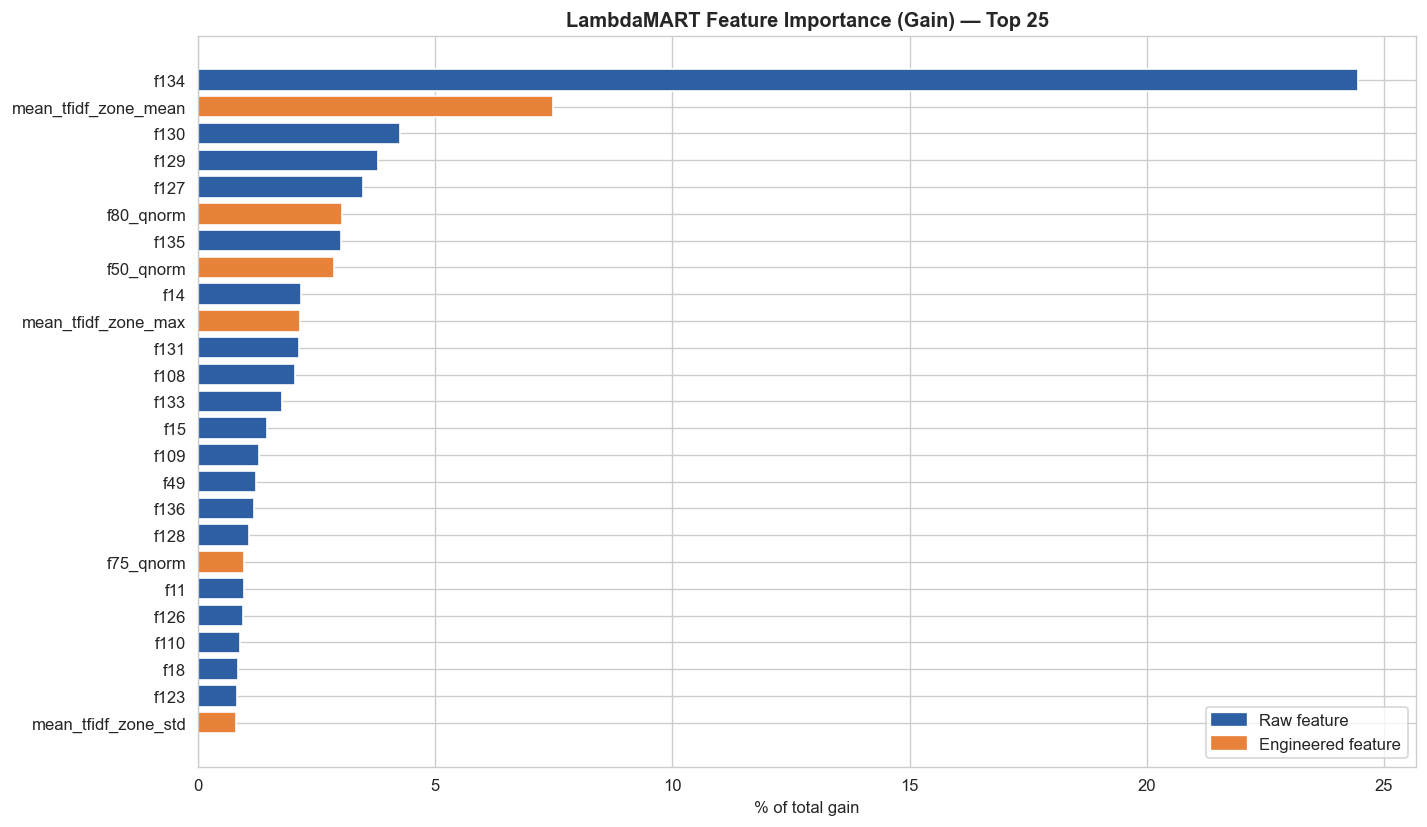

Engineered features in top 25: 6
             feature  gain_pct
mean_tfidf_zone_mean  7.493327
           f80_qnorm  3.026106
           f50_qnorm  2.865810
 mean_tfidf_zone_max  2.148458
           f75_qnorm  0.974311
 mean_tfidf_zone_std  0.793275


In [10]:
# Visualisig top 25 features by gain
top25 = importance.head(25)
# Tagging engineered vs raw
raw_feats = [f'f{i}' for i in range(1, 137)]
colors = ['#E8813A' if f not in raw_feats else '#2E5FA3'
          for f in top25['feature']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top25['feature'][::-1], top25['gain_pct'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_title('LambdaMART Feature Importance (Gain) — Top 25',
             fontweight='bold')
ax.set_xlabel('% of total gain')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2E5FA3', label='Raw feature'),
    Patch(color='#E8813A', label='Engineered feature'),
], loc='lower right')

plt.tight_layout()
plt.savefig('outputs/plots/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Identifying how many engineered features made top 25
eng_in_top25 = top25[~top25['feature'].isin(raw_feats)]
print(f'Engineered features in top 25: {len(eng_in_top25)}')
print(eng_in_top25[['feature', 'gain_pct']].to_string(index=False))

### Learning Curves

> Plotting NDCG@10 on train and validation as a function of boosting rounds.
> This shows whether the model is underfitting or overfitting.

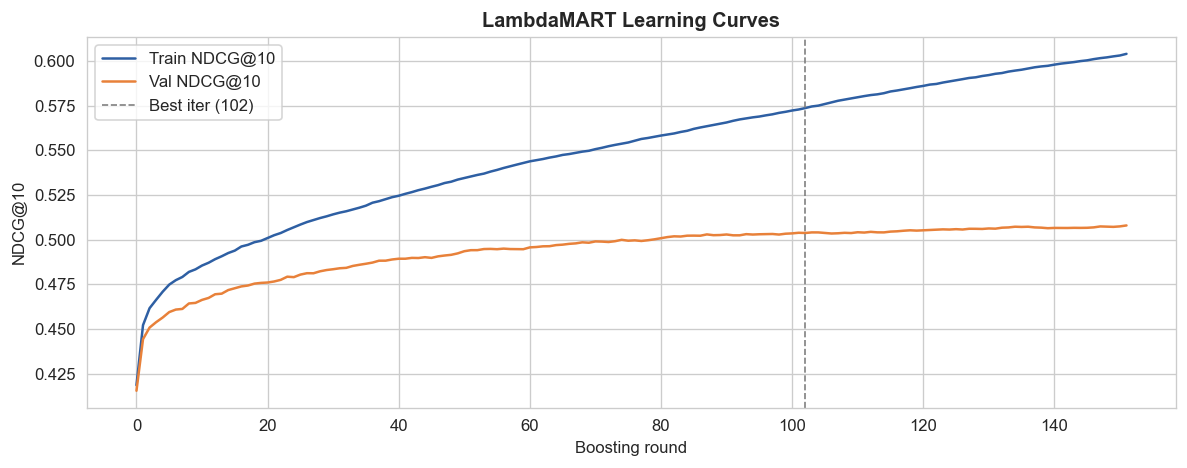

In [11]:
# Re-training with evaluation recording to get learning curves
evals_result = {}
callbacks_lc = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.record_evaluation(evals_result),
    lgb.log_evaluation(period=200)
]

lgb_train_lc = lgb.Dataset(X_train, label=y_train, group=q_train)
lgb_val_lc   = lgb.Dataset(X_val,   label=y_val,   group=q_val, reference=lgb_train_lc)

model = lgb.train(
    params_lambdamart,
    lgb_train_lc,
    num_boost_round=model_lambdamart.best_iteration + 50,
    valid_sets=[lgb_train_lc, lgb_val_lc],
    valid_names=['train', 'val'],
    callbacks=callbacks_lc
)

# Plot
val_ndcg = evals_result['val']['ndcg@10']
trn_ndcg = evals_result['train']['ndcg@10']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trn_ndcg, color='#2E5FA3', lw=1.5, label='Train NDCG@10')
ax.plot(val_ndcg,  color='#E8813A', lw=1.5, label='Val NDCG@10')
ax.axvline(model_lambdamart.best_iteration, color='gray',
           linestyle='--', lw=1, label=f'Best iter ({model_lambdamart.best_iteration})')
ax.set_title('LambdaMART Learning Curves', fontweight='bold')
ax.set_xlabel('Boosting round')
ax.set_ylabel('NDCG@10')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/03_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Interim Results & Business KPIs

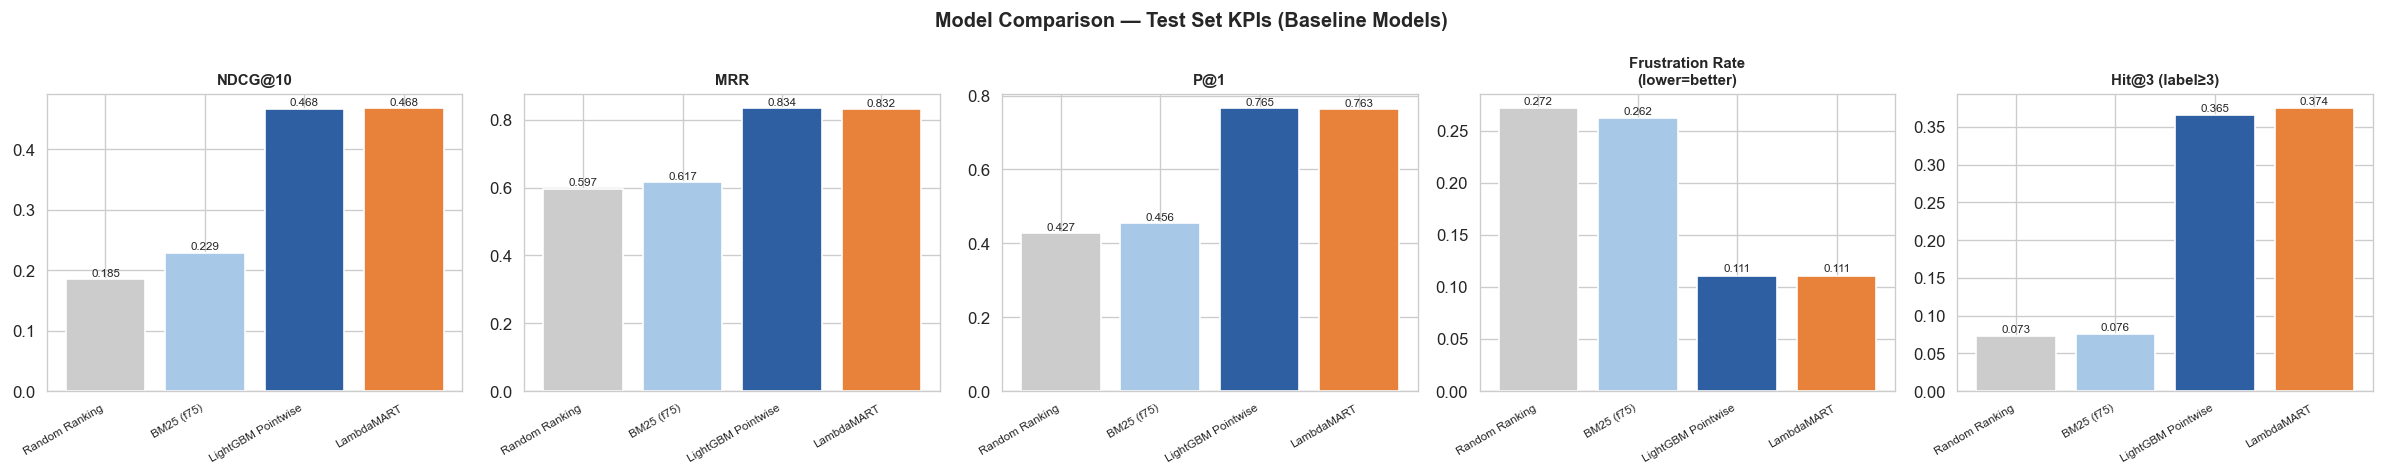

In [12]:
results_df = pd.DataFrame(all_results).T

# KPI comparison chart
kpi_cols = ['ndcg@10', 'mrr', 'p@1', 'frustration_rate', 'hit@3_highly_rel']
kpi_labels = ['NDCG@10', 'MRR', 'P@1', 'Frustration Rate\n(lower=better)', 'Hit@3 (label≥3)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Model Comparison — Test Set KPIs (Baseline Models)',
             fontweight='bold', fontsize=12)

model_colors = {
    'Random Ranking'    : '#CCCCCC',
    'BM25 (f75)'        : '#A8C8E8',
    'LightGBM Pointwise': '#2E5FA3',
    'LambdaMART'        : '#E8813A',
}

for ax, col, label in zip(axes, kpi_cols, kpi_labels):
    vals   = results_df[col]
    colors = [model_colors.get(m, '#999') for m in vals.index]
    bars   = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=7)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/plots/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Saving results
results_df.to_csv('outputs/results/model_results.csv')

In [17]:
lm = kpis_lambdamart
bm = baselines.loc['BM25 (f75)']
rnd = baselines.loc['Random Ranking']

print(f"""
Baseline Models - Summary

Model Results (Test Set)
                     NDCG@10    MRR      P@1    Frustration  Hit@3
Random Ranking:      {rnd['ndcg@10']:.4f}    {rnd['mrr']:.4f}   {rnd['p@1']:.4f}     {rnd['frustration_rate']:.4f}    {rnd['hit@3_highly_rel']:.4f}
BM25 (f75):          {bm['ndcg@10']:.4f}    {bm['mrr']:.4f}   {bm['p@1']:.4f}     {bm['frustration_rate']:.4f}    {bm['hit@3_highly_rel']:.4f}
LightGBM Pointwise:  {kpis_pointwise['ndcg@10']:.4f}    {kpis_pointwise['mrr']:.4f}   {kpis_pointwise['p@1']:.4f}     {kpis_pointwise['frustration_rate']:.4f}    {kpis_pointwise['hit@3_highly_rel']:.4f}
LambdaMART:          {lm['ndcg@10']:.4f}    {lm['mrr']:.4f}   {lm['p@1']:.4f}     {lm['frustration_rate']:.4f}    {lm['hit@3_highly_rel']:.4f}

Key Insights:
  - LambdaMART >> Pointwise — confirms listwise objective matters
  - Both models beat BM25 significantly — 136 features >> single BM25 score
  - Frustration rate reduced by {(bm['frustration_rate'] - lm['frustration_rate']):.1%} vs BM25
  - Engineered features contributed meaningfully to feature importance
""")


Baseline Models - Summary

Model Results (Test Set)
                     NDCG@10    MRR      P@1    Frustration  Hit@3
Random Ranking:      0.1847    0.5973   0.4275     0.2715    0.0735
BM25 (f75):          0.2291    0.6172   0.4555     0.2620    0.0760
LightGBM Pointwise:  0.4676    0.8338   0.7655     0.1105    0.3655
LambdaMART:          0.4678    0.8320   0.7630     0.1110    0.3745

Key Insights:
  - LambdaMART >> Pointwise — confirms listwise objective matters
  - Both models beat BM25 significantly — 136 features >> single BM25 score
  - Frustration rate reduced by 15.1% vs BM25
  - Engineered features contributed meaningfully to feature importance

